# 11 - Rail network analysis

We want to isolate the heavy-rail part of the national GTFS feed and measure its vulnerability without the approximations needed for the much larger all-mode graph. The rail layer has only 67 active stations in this snapshot, so we can calculate centrality exactly, try removing every station one at a time, and run many random-failure sequences.

The question is: **which rail stations are genuine connectivity bottlenecks, and how different is a targeted closure from a random one?**

We read `routes.txt`, `trips.txt`, `stops.txt`, and `calendar.txt`, then stream only rail trips out of the large `stop_times.txt`. Under `outputs/nb/11_rail_network_analysis/` we save the mode inventory, rail graph edges, station metrics, articulation points, bridges, single-station damage, resilience curves, a JSON summary, and five figures.

Two limits apply to everything here:

1. An edge means two stations are consecutive stops in a scheduled service. Express trains can create an edge between stations that are not adjacent pieces of track, so this is a service graph rather than a physical infrastructure map.
2. Edge weights count GTFS trip records in the snapshot, not trains per week or passengers. We use unweighted topology for articulation points, bridges, betweenness, and fragmentation; weighted degree and PageRank are the measures that inherit the frequency caveat.

## Set up the repository and output paths

We locate the project, switch into it, and create the shared notebook output folder. The helper installs only missing packages and can clone the project in Colab. It is safe to rerun, and every later path is based on the `REPO`, `DATA`, and `OUT` values created here.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## Load libraries and set the experiment size

We import NetworkX, pandas, NumPy, plotting libraries, and SciPy, then create this notebook's `tables` and `figures` folders.

The rail graph is small enough for exact centrality. The main repeated work is the random-failure baseline: `RANDOM_TRIALS` random orders evaluated through `MAX_REMOVALS`. `SEED` fixes both Louvain and those random orders. The other constants control figure resolution and how many stations we show in ranked tables.

In [2]:
_ensure("networkx", "pandas", "numpy", "matplotlib", "seaborn", "scipy")

import csv
import json
import random
import time
from collections import Counter, defaultdict

import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# --- Analysis constants -------------------------------------------------
RAIL_ROUTE_TYPE = "2"   # GTFS route_type 2 = heavy rail (Israel Railways)
SEED = 42               # fixes Louvain communities and random-failure orderings
RANDOM_TRIALS = 500     # Monte-Carlo repetitions for the random-failure baseline
MAX_REMOVALS = 15       # how far the resilience curves run along the x-axis

# --- Stage output folders ----------------------------------------------
STAGE = OUT / "11_rail_network_analysis"
TABLES = STAGE / "tables"
FIGURES = STAGE / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print("networkx", nx.__version__, "| pandas", pd.__version__)
print("Stage folder:", STAGE)

networkx 3.6.1 | pandas 3.0.5
Stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/11_rail_network_analysis


## Make sure `stop_times.txt` is available

The stop-times table is about 778 MB on disk and is not stored with the smaller GTFS files. We check for it and download it only when missing. The download is cached, because the rail filter still has to scan the entire file even though fewer than one tenth of one percent of its rows are rail.

In [3]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## Prepare Hebrew text for matplotlib

This matplotlib build already handles Hebrew text direction, so we pass raw station names through unchanged and keep `fix_he` as a no-op. We select a Hebrew-capable font, disable scientific-offset formatting, and remove any leftover bidirectional patch that could reverse labels twice.

In [4]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

# We pass raw Hebrew strings to Matplotlib from here on because this build handles bidi.
# Calling a second reordering helper would reverse the text twice.

## Load GTFS metadata and count each transport mode

We read routes, trips, stops, and calendar columns as strings so identifiers keep leading zeros. Then we join trips to routes and count route records and scheduled trips by `route_type`. This inventory shows the relative size of rail before we spend time scanning the stop events and gives us a check that the mode code is being interpreted correctly.

In [5]:
def read_gtfs(path):
    """Read a GTFS table as strings. Fails loudly on a missing or placeholder file."""
    if not path.exists() or path.stat().st_size < 100:
        raise FileNotFoundError(
            f"Missing or unhydrated GTFS file: {path}. "
            "Check that the israel-public-transportation folder was cloned in full."
        )
    return pd.read_csv(path, dtype=str, encoding="utf-8-sig")

def route_type_label(route_type):
    """Human-readable name for the GTFS route_type codes used in this feed."""
    return {
        "0": "tram/light rail",
        "2": "rail",
        "3": "bus",
        "5": "cable tram",
        "8": "trolleybus/taxi-coded",
        "715": "demand/other bus",
    }.get(str(route_type), "other")

def mode_inventory(routes, trips):
    """Route records and scheduled trips per mode."""
    route_counts = routes.groupby("route_type").size().rename("route_records")
    trip_counts = (
        trips.merge(routes[["route_id", "route_type"]], on="route_id", how="left")
        .groupby("route_type")
        .size()
        .rename("scheduled_trips")
    )
    inventory = pd.concat([route_counts, trip_counts], axis=1).fillna(0).reset_index()
    inventory["route_type_label"] = inventory["route_type"].map(route_type_label)
    inventory["route_records"] = inventory["route_records"].astype(int)
    inventory["scheduled_trips"] = inventory["scheduled_trips"].astype(int)
    return inventory[
        ["route_type", "route_type_label", "route_records", "scheduled_trips"]
    ]

routes = read_gtfs(DATA / "routes.txt")
trips = read_gtfs(DATA / "trips.txt")
stops = read_gtfs(DATA / "stops.txt")
calendar = read_gtfs(DATA / "calendar.txt")

inventory = mode_inventory(routes, trips)
print(f"routes={len(routes):,}  trips={len(trips):,}  stops={len(stops):,}")
inventory

routes=7,792  trips=420,133  stops=34,932


,route_type,route_type_label,route_records,scheduled_trips
0,0,tram/light rail,8,2890
1,2,rail,962,1188
2,3,bus,6796,412544
3,5,cable tram,4,3006
4,715,demand/other bus,14,458
5,8,trolleybus/taxi-coded,8,47


## Select the heavy-rail trips

We keep routes with `route_type = 2`, collect their trip IDs, and look up the relevant service IDs in the calendar. We print route records, distinct route names, scheduled trip records, and the active date window. The date range matters because the graph describes one timetable snapshot, not a permanent rail layout.

In [6]:
rail_routes = routes[routes["route_type"] == RAIL_ROUTE_TYPE].copy()
rail_trips = trips[trips["route_id"].isin(rail_routes["route_id"])].copy()
if rail_routes.empty or rail_trips.empty:
    raise RuntimeError("The GTFS feed contains no route_type=2 rail service")

def service_date_range(rail_trips, calendar):
    """Earliest start and latest end date of the calendars used by rail trips."""
    relevant = calendar[calendar["service_id"].isin(rail_trips["service_id"])]
    if relevant.empty:
        return "", ""
    def iso_date(raw):
        raw = str(raw)
        return f"{raw[:4]}-{raw[4:6]}-{raw[6:8]}" if len(raw) == 8 else raw
    return iso_date(relevant["start_date"].min()), iso_date(relevant["end_date"].max())

start_date, end_date = service_date_range(rail_trips, calendar)
rail_trip_ids = set(rail_trips["trip_id"])

print(f"rail route records      : {len(rail_routes):,}")
print(f"unique route long names : {rail_routes['route_long_name'].nunique():,}")
print(f"scheduled rail trips    : {len(rail_trips):,}")
print(f"service window          : {start_date} .. {end_date}")

rail route records      : 962
unique route long names : 82
scheduled rail trips    : 1,188
service window          : 2026-04-19 .. 2026-05-19


## Stream only rail stop events from the large file

We read `stop_times.txt` with `csv.reader`, map the header once, and retain rows only when their `trip_id` is in the rail set. For each retained trip we store `(stop_sequence, stop_id)` and count scheduled calls at each station.

This is the slowest cell because all 15.7 million rows must be inspected. Sorting each retained trip by `stop_sequence` later protects against relying on file order. We print scanned rows, kept rows, trip count, and rail share so we can verify the filter.

In [7]:
def collect_rail_stop_times(stop_times_path, rail_trip_ids, progress_every=2_000_000):
    """Stream the national stop-times file but retain only the small rail subset.

    Returns (sequences, stop_use_counts, total_rows_seen, rail_rows_kept).
    """
    sequences = defaultdict(list)
    stop_use_counts = Counter()
    all_rows = 0
    rail_rows = 0
    with stop_times_path.open(encoding="utf-8-sig", newline="") as handle:
        reader = csv.reader(handle)
        header = next(reader)
        required = {"trip_id", "stop_id", "stop_sequence"}
        if not required.issubset(set(header)):
            raise ValueError(f"stop_times.txt is missing fields: {sorted(required)}")
        i_trip = header.index("trip_id")
        i_stop = header.index("stop_id")
        i_seq = header.index("stop_sequence")
        t0 = time.perf_counter()
        for row in reader:
            all_rows += 1
            if progress_every and all_rows % progress_every == 0:
                print(f"  scanned {all_rows:,} rows | kept {rail_rows:,} rail rows "
                      f"| {time.perf_counter() - t0:.0f}s", flush=True)
            if row[i_trip] not in rail_trip_ids:
                continue
            rail_rows += 1
            try:
                sequence = int(float(row[i_seq]))
            except ValueError:
                continue  # unparsable sequence: the row cannot be ordered, so skip it
            stop_id = row[i_stop]
            sequences[row[i_trip]].append((sequence, stop_id))
            stop_use_counts[stop_id] += 1
    return sequences, stop_use_counts, all_rows, rail_rows

_t0 = time.perf_counter()
sequences, stop_calls, source_rows, rail_rows = collect_rail_stop_times(
    STOP_TIMES, rail_trip_ids
)
print(f"scanned {source_rows:,} stop-time rows in {time.perf_counter() - _t0:.1f}s")
print(f"kept {rail_rows:,} rail rows across {len(sequences):,} trips")
print(f"rail share of the feed: {100 * rail_rows / max(source_rows, 1):.4f}%")

  scanned 2,000,000 rows | kept 14,601 rail rows | 1s
  scanned 4,000,000 rows | kept 14,601 rail rows | 2s
  scanned 6,000,000 rows | kept 14,601 rail rows | 2s
  scanned 8,000,000 rows | kept 14,601 rail rows | 3s
  scanned 10,000,000 rows | kept 14,601 rail rows | 4s
  scanned 12,000,000 rows | kept 14,601 rail rows | 5s
  scanned 14,000,000 rows | kept 14,601 rail rows | 6s
scanned 15,711,624 stop-time rows in 6.4s
kept 14,601 rail rows across 1,188 trips
rail share of the feed: 0.0929%


## Build directed and undirected rail graphs

For every rail trip we sort its stops by sequence and turn each consecutive pair into a directed service edge. Repeated uses increase the weight; duplicate self-pairs are ignored. We then build an undirected view by combining both directions and summing their weights.

The directed graph is useful for PageRank and the service-edge export. We use the undirected graph for structural centrality and closure tests because a closed station blocks both travel directions. The cell prints stations, directed edges, undirected edges, and connected components as a topology check.

In [8]:
def build_graphs(sequences):
    """Turn per-trip stop sequences into a weighted directed graph and its undirected view."""
    edge_counts = Counter()
    nodes = set()
    for trip_sequence in sequences.values():
        ordered = [stop for _, stop in sorted(trip_sequence)]
        nodes.update(ordered)
        for source, target in zip(ordered, ordered[1:]):
            if source != target:  # ignore duplicated rows for the same station
                edge_counts[(source, target)] += 1

    directed = nx.DiGraph()
    directed.add_nodes_from(nodes)
    for (source, target), weight in edge_counts.items():
        directed.add_edge(source, target, weight=int(weight))

    undirected = nx.Graph()
    undirected.add_nodes_from(nodes)
    for source, target, data in directed.edges(data=True):
        weight = int(data["weight"])
        if undirected.has_edge(source, target):
            undirected[source][target]["weight"] += weight
        else:
            undirected.add_edge(source, target, weight=weight)
    return directed, undirected

directed, undirected = build_graphs(sequences)
print(f"stations               : {undirected.number_of_nodes()}")
print(f"directed service edges : {directed.number_of_edges()}")
print(f"undirected service edges: {undirected.number_of_edges()}")
print(f"connected components   : {nx.number_connected_components(undirected)}")

stations               : 67
directed service edges : 197
undirected service edges: 99
connected components   : 1


## Attach names and coordinates to the graph nodes

We join each active rail `stop_id` to its GTFS name, code, latitude, and longitude. We explicitly fail if a graph node has no metadata row or if its coordinates are not numeric. That gives us readable tables and prevents a missing coordinate from silently corrupting the map.

In [9]:
def attach_stop_metadata(directed, undirected, stops):
    """Copy name/code/lat/lon onto the nodes; return the active-stop table."""
    active = stops[stops["stop_id"].isin(undirected.nodes)].copy()

    missing = set(undirected.nodes) - set(active["stop_id"])
    if missing:
        raise KeyError(
            f"{len(missing)} rail stop_id(s) appear in stop_times.txt but not in stops.txt "
            f"(e.g. {sorted(missing)[:5]}). The GTFS feed files are out of sync - "
            "re-download israel-public-transportation/ and stop_times.txt from the same snapshot."
        )

    active["stop_lat"] = pd.to_numeric(active["stop_lat"], errors="coerce")
    active["stop_lon"] = pd.to_numeric(active["stop_lon"], errors="coerce")
    bad_coords = active[active[["stop_lat", "stop_lon"]].isna().any(axis=1)]
    if not bad_coords.empty:
        raise ValueError(
            f"{len(bad_coords)} rail stops have unparsable coordinates: "
            f"{bad_coords['stop_id'].tolist()[:5]}"
        )

    active = active.set_index("stop_id", drop=False)
    for stop_id in undirected.nodes:
        row = active.loc[stop_id]
        attributes = {
            "stop_name": row.get("stop_name", ""),
            "stop_code": row.get("stop_code", ""),
            "lat": float(row["stop_lat"]),
            "lon": float(row["stop_lon"]),
        }
        directed.nodes[stop_id].update(attributes)
        undirected.nodes[stop_id].update(attributes)
    return active.reset_index(drop=True)

active_stops = attach_stop_metadata(directed, undirected, stops)
print(f"metadata attached for {len(active_stops)} active rail stations")
active_stops[["stop_id", "stop_code", "stop_name", "stop_lat", "stop_lon"]].head()

metadata attached for 67 active rail stations


,stop_id,stop_code,stop_name,stop_lat,stop_lon
0,37290,17106,שדרות,31.515877,34.586059
1,37292,17104,תל אביב ההגנה,32.053978,34.784839
2,37294,17102,רשל''צ משה דיין,31.987987,34.757392
3,37296,17100,הוד השרון,32.170213,34.901609
4,37298,17098,ראשונים,31.948927,34.802622


## Calculate exact station metrics and graph cuts

With 67 stations we can calculate every measure without sampling:

- degree and weighted degree for neighbors and scheduled service volume;
- weighted PageRank on the directed graph;
- exact unweighted betweenness on the undirected graph;
- normalized harmonic centrality for reach, even if a rerun is disconnected;
- articulation points and bridges for strict connectivity failures;
- seeded weighted Louvain communities for service clusters.

We keep betweenness unweighted because we want shortest paths in structural hops, not a distance made smaller by high frequency. The resulting station table combines all of these measures with the metadata and prints the highest-betweenness rows.

In [10]:
def compute_metrics(directed, undirected, stop_use_counts, active_stops, seed):
    """Per-station metric table plus the bridge table. All values are exact."""
    degree = dict(undirected.degree())
    weighted_degree = dict(undirected.degree(weight="weight"))
    pagerank = nx.pagerank(directed, weight="weight")
    # normalized=True, weight=None -> exact, hop-based betweenness over all 67 sources
    betweenness = nx.betweenness_centrality(undirected, normalized=True, weight=None)
    harmonic_raw = nx.harmonic_centrality(undirected)
    harmonic_denominator = max(1, undirected.number_of_nodes() - 1)
    harmonic = {n: v / harmonic_denominator for n, v in harmonic_raw.items()}
    articulation = set(nx.articulation_points(undirected))
    bridges = set(nx.bridges(undirected))

    communities = nx.community.louvain_communities(undirected, weight="weight", seed=seed)
    community_by_node = {}
    for community_id, members in enumerate(sorted(communities, key=len, reverse=True), start=1):
        for node in members:
            community_by_node[node] = community_id

    metadata = active_stops.set_index("stop_id")
    rows = []
    for node in undirected.nodes:
        row = metadata.loc[node]
        rows.append(
            {
                "stop_id": node,
                "stop_code": row.get("stop_code", ""),
                "stop_name": row.get("stop_name", ""),
                "stop_lat": float(row["stop_lat"]),
                "stop_lon": float(row["stop_lon"]),
                "scheduled_stop_calls": int(stop_use_counts[node]),
                "degree": int(degree[node]),
                "weighted_degree": int(weighted_degree[node]),
                "in_degree": int(directed.in_degree(node)),
                "out_degree": int(directed.out_degree(node)),
                "pagerank": float(pagerank[node]),
                "betweenness": float(betweenness[node]),
                "harmonic": float(harmonic[node]),
                "is_articulation_point": node in articulation,
                "community_id": int(community_by_node[node]),
            }
        )
    metrics = pd.DataFrame(rows)

    names = metrics.set_index("stop_id")["stop_name"].to_dict()
    bridge_rows = [
        {
            "from_stop_id": source,
            "from_stop_name": names[source],
            "to_stop_id": target,
            "to_stop_name": names[target],
            "scheduled_trip_segments": int(undirected[source][target]["weight"]),
        }
        for source, target in sorted(bridges)
    ]
    return metrics, pd.DataFrame(bridge_rows)

_t0 = time.perf_counter()
metrics, bridges = compute_metrics(directed, undirected, stop_calls, active_stops, SEED)
print(f"exact metrics for {len(metrics)} stations in {time.perf_counter() - _t0:.2f}s")
metrics.nlargest(10, "betweenness")[
    ["stop_name", "degree", "weighted_degree", "betweenness", "pagerank",
     "is_articulation_point"]
]

exact metrics for 67 stations in 0.01s


,stop_name,degree,weighted_degree,betweenness,pagerank,is_articulation_point
12,תל אביב ההגנה,8,1493,0.537840,0.039443,True
3,הרצליה,8,846,0.514608,0.022429,False
14,תל אביב מרכז,4,1543,0.508625,0.031372,True
5,לוד,8,557,0.398213,0.029739,True
41,חוף הכרמל,6,688,0.364180,0.020354,True
27,חיפה מרכז,7,815,0.339860,0.025639,True
33,נתב''ג,4,617,0.310023,0.018163,True
23,השלום,2,1502,0.221911,0.032019,False
35,קרית גת,4,140,0.184149,0.012144,False
20,קרית מוצקין,6,624,0.158974,0.023180,True


## Summarize the whole rail graph

We calculate node and edge counts, component coverage, average degree, density, clustering, shortest-path length, diameter, number of cut vertices and cut edges, and Louvain community count. Path length and diameter use the largest component if the graph is not connected. This one-row summary is the quickest description of how sparse and branch-like the rail service graph is.

In [11]:
def network_summary(graph, directed, metrics, communities):
    components = list(nx.connected_components(graph))
    largest = graph.subgraph(max(components, key=len)).copy()
    return {
        "active_stations": graph.number_of_nodes(),
        "directed_service_edges": directed.number_of_edges(),
        "undirected_service_edges": graph.number_of_edges(),
        "connected_components": len(components),
        "largest_component_stations": largest.number_of_nodes(),
        "largest_component_share": largest.number_of_nodes() / graph.number_of_nodes(),
        "average_degree": sum(dict(graph.degree()).values()) / graph.number_of_nodes(),
        "density": nx.density(graph),
        "average_clustering": nx.average_clustering(graph),
        "average_shortest_path_hops_lcc": nx.average_shortest_path_length(largest),
        "diameter_hops_lcc": nx.diameter(largest),
        "articulation_points": int(metrics["is_articulation_point"].sum()),
        "bridges": int(sum(1 for _ in nx.bridges(graph))),
        "louvain_communities": communities,
    }

n_communities = metrics["community_id"].nunique()
summary = network_summary(undirected, directed, metrics, n_communities)
for key, value in summary.items():
    print(f"{key:34s} {value:.4f}" if isinstance(value, float) else f"{key:34s} {value}")

active_stations                    67
directed_service_edges             197
undirected_service_edges           99
connected_components               1
largest_component_stations         67
largest_component_share            1.0000
average_degree                     2.9552
density                            0.0448
average_clustering                 0.3653
average_shortest_path_hops_lcc     5.6260
diameter_hops_lcc                  13
articulation_points                14
bridges                            11
louvain_communities                8


## Inspect the articulation points and bridges

We turn the cut vertices and cut edges into readable tables with station names, service volume, betweenness, and community. These are threshold-free structural results: removing an articulation station, or the only edge between two parts, increases the component count.

We compare them with centrality rather than assuming the rankings are identical. A low-volume branch gateway can be a cut vertex even when it carries only a small fraction of all shortest paths.

In [12]:
articulation_points = (
    metrics[metrics["is_articulation_point"]]
    .sort_values("betweenness", ascending=False)
    [["stop_id", "stop_code", "stop_name", "degree", "weighted_degree",
      "betweenness", "community_id"]]
    .reset_index(drop=True)
)
print(f"articulation points: {len(articulation_points)}")
print(f"bridges            : {len(bridges)}")
display(articulation_points)
display(bridges.sort_values("scheduled_trip_segments", ascending=False).reset_index(drop=True))

articulation points: 14
bridges            : 11


,stop_id,stop_code,stop_name,degree,weighted_degree,betweenness,community_id
0,37292,17104,תל אביב ההגנה,8,1493,0.537840,5
1,37358,17038,תל אביב מרכז,4,1543,0.508625,5
2,37338,17058,לוד,8,557,0.398213,1
3,37376,17020,חוף הכרמל,6,688,0.364180,2
4,37380,17016,חיפה מרכז,7,815,0.339860,2
5,37306,17090,נתב''ג,4,617,0.310023,5
6,41293,17117,קרית מוצקין,6,624,0.158974,6
7,37314,17082,באר שבע צפון,5,454,0.113287,4
8,40581,17113,כפר ברוך,4,212,0.059674,2
9,37336,17060,רמלה,3,204,0.056177,1


,from_stop_id,from_stop_name,to_stop_id,to_stop_name,scheduled_trip_segments
0,37396,פאתי מודיעין,37394,מודיעין מרכז,233
1,37312,באר שבע מרכז,37314,באר שבע צפון,219
2,37384,עכו,37382,נהריה,187
3,37384,עכו,41293,קרית מוצקין,187
4,41291,אחיהוד,41292,כרמיאל,121
5,41291,אחיהוד,41293,קרית מוצקין,121
6,40582,עפולה,40581,כפר ברוך,106
7,40583,בית שאן,40582,עפולה,106
8,37338,לוד,37298,ראשונים,59
9,37322,בית שמש,37336,רמלה,50


## Simulate every possible single-station closure

We remove each station in turn, recompute connected components, and record the number of pieces, largest surviving component, stations left outside it, and two serviceable shares.

`largest_component_share_of_remaining` divides by the stations still open. `serviceable_share_of_original` divides the largest surviving component by the original 67, so it includes both the removed station and any disconnected stations. We rank by actual fragmentation damage; this brute-force table is the standard against which the centrality proxies can be checked.

In [13]:
def graph_state(graph, removed):
    """Connectivity of the graph after deleting the given stations."""
    remaining = set(graph.nodes).difference(removed)
    original_nodes = graph.number_of_nodes()
    if not remaining:
        return {
            "remaining_stations": 0,
            "components": 0,
            "largest_component_nodes": 0,
            "largest_component_share_of_remaining": 0.0,
            "serviceable_share_of_original": 0.0,
        }
    subgraph = graph.subgraph(remaining)
    component_sizes = [len(c) for c in nx.connected_components(subgraph)]
    largest = max(component_sizes)
    return {
        "remaining_stations": len(remaining),
        "components": len(component_sizes),
        "largest_component_nodes": largest,
        "largest_component_share_of_remaining": largest / len(remaining),
        "serviceable_share_of_original": largest / original_nodes,
    }

def single_station_damage(graph, metrics):
    """Exhaustively close each station in turn and measure the fragmentation."""
    names = metrics.set_index("stop_id")["stop_name"].to_dict()
    rows = []
    for node in graph.nodes:
        state = graph_state(graph, [node])
        rows.append(
            {
                "stop_id": node,
                "stop_name": names[node],
                **state,
                "stations_outside_largest_component": int(
                    state["remaining_stations"] - state["largest_component_nodes"]
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ["stations_outside_largest_component", "components", "stop_name"],
        ascending=[False, False, True],
    )

damage = single_station_damage(undirected, metrics)
worst = damage.iloc[0]
print(
    f"Worst single closure: {worst['stop_name']} -> "
    f"{worst['components']} components, only "
    f"{100 * worst['serviceable_share_of_original']:.1f}% of stations still connected"
)
damage.head(12)[
    ["stop_name", "components", "largest_component_nodes",
     "stations_outside_largest_component", "serviceable_share_of_original"]
]

Worst single closure: תל אביב מרכז -> 2 components, only 49.3% of stations still connected


,stop_name,components,largest_component_nodes,stations_outside_largest_component,serviceable_share_of_original
14,תל אביב מרכז,2,33,33,0.492537
12,תל אביב ההגנה,2,39,27,0.582090
41,חוף הכרמל,2,51,15,0.761194
27,חיפה מרכז,3,53,13,0.791045
20,קרית מוצקין,3,62,4,0.925373
33,נתב''ג,2,63,3,0.940299
37,באר שבע צפון,3,64,2,0.955224
42,כפר ברוך,2,64,2,0.955224
19,אחיהוד,2,65,1,0.970149
5,לוד,2,65,1,0.970149


## Compare targeted and random removal sequences

We create static attack orders based on degree, weighted degree, PageRank, betweenness, and an articulation/damage-first rule. For each order we remove up to `MAX_REMOVALS` stations and track the largest component as a share of the original graph.

For the baseline we repeat the same number of removals across `RANDOM_TRIALS` random orders and average the curve. The rankings are calculated once on the intact graph, so this represents a plan made from the original network rather than an adaptive strategy that recomputes after every closure.

In [14]:
def resilience_curves(graph, metrics, damage, max_removals, random_trials, seed):
    damage_rank = damage.set_index("stop_id")["stations_outside_largest_component"]
    ranked = metrics.copy()
    ranked["single_station_damage"] = ranked["stop_id"].map(damage_rank)
    rankings = {
        "degree": ranked.sort_values(
            ["degree", "weighted_degree"], ascending=False
        )["stop_id"].tolist(),
        "weighted_degree": ranked.sort_values("weighted_degree", ascending=False)[
            "stop_id"
        ].tolist(),
        "pagerank": ranked.sort_values("pagerank", ascending=False)["stop_id"].tolist(),
        "betweenness": ranked.sort_values("betweenness", ascending=False)[
            "stop_id"
        ].tolist(),
        "articulation_priority": ranked.sort_values(
            ["is_articulation_point", "single_station_damage", "degree"],
            ascending=False,
        )["stop_id"].tolist(),
    }
    max_removals = min(max_removals, graph.number_of_nodes() - 1)

    rows = []
    for strategy, ranking in rankings.items():
        for removed_count in range(max_removals + 1):
            rows.append(
                {
                    "strategy": strategy,
                    "removed_stations": removed_count,
                    **graph_state(graph, ranking[:removed_count]),
                }
            )

    rng = random.Random(seed)  # seeded so the baseline is reproducible
    nodes = list(graph.nodes)
    random_states = defaultdict(list)
    for _ in range(random_trials):
        ordering = rng.sample(nodes, len(nodes))
        for removed_count in range(max_removals + 1):
            random_states[removed_count].append(graph_state(graph, ordering[:removed_count]))
    for removed_count, states in random_states.items():
        row = {"strategy": "random_mean", "removed_stations": removed_count}
        for field in states[0]:
            row[field] = float(np.mean([float(state[field]) for state in states]))
        rows.append(row)
    return pd.DataFrame(rows)

_t0 = time.perf_counter()
resilience = resilience_curves(
    undirected, metrics, damage, MAX_REMOVALS, RANDOM_TRIALS, SEED
)
print(f"resilience curves computed in {time.perf_counter() - _t0:.1f}s")
resilience.pivot(
    index="removed_stations", columns="strategy", values="serviceable_share_of_original"
).round(3)

resilience curves computed in 0.7s


strategy,articulation_priority,betweenness,degree,pagerank,random_mean,weighted_degree
removed_stations,,,,,,
0,1.000,1.000,1.000,1.000,1.000,1.000
1,0.493,0.582,0.582,0.582,0.951,0.493
2,0.493,0.567,0.567,0.567,0.917,0.493
3,0.403,0.478,0.567,0.493,0.879,0.493
4,0.403,0.478,0.358,0.478,0.838,0.478
5,0.403,0.343,0.343,0.478,0.799,0.403
6,0.403,0.343,0.343,0.478,0.766,0.403
7,0.358,0.343,0.343,0.269,0.725,0.403
8,0.358,0.343,0.224,0.269,0.691,0.403


## Compare one informed closure with one random closure

We take the most damaging row from the exhaustive single-station table and compare its remaining largest-component share with the random curve after one removal. This is the cleanest targeted-versus-random result because both scenarios close exactly one station and require no choice about how to rank a long sequence.

In [15]:
worst_row = damage.iloc[0]
random_one = resilience[
    (resilience["strategy"] == "random_mean") & (resilience["removed_stations"] == 1)
].iloc[0]

targeted_pct = 100 * float(worst_row["serviceable_share_of_original"])
random_pct = 100 * float(random_one["serviceable_share_of_original"])
print(f"Closing the single worst station ({worst_row['stop_name']}):")
print(f"  largest connected component = {targeted_pct:.1f}% of the original network")
print(f"  network splits into {int(worst_row['components'])} components")
print(f"Closing one station at random (mean of {RANDOM_TRIALS} trials):")
print(f"  largest connected component = {random_pct:.1f}% of the original network")
print(f"Gap: {random_pct - targeted_pct:.1f} percentage points from one informed choice.")

Closing the single worst station (תל אביב מרכז):
  largest connected component = 49.3% of the original network
  network splits into 2 components
Closing one station at random (mean of 500 trials):
  largest connected component = 95.1% of the original network
Gap: 45.8 percentage points from one informed choice.


## Draw the rail-network figures

The next plotting helpers produce five views:

1. a coordinate map with color for exact betweenness and size for weighted degree;
2. a ranked betweenness bar chart;
3. a ranked single-station damage chart;
4. targeted and random resilience curves;
5. a Spearman correlation heatmap across the station measures.

We save each figure to this stage folder and display it in the notebook so we can check labels and outliers immediately.

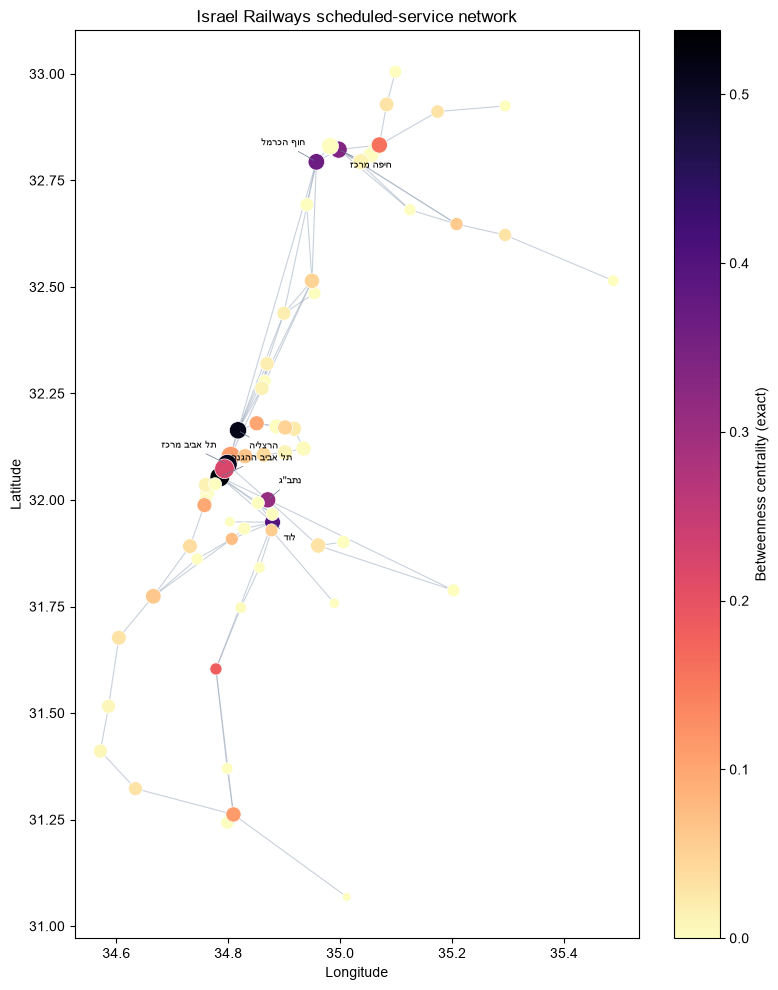

In [16]:
def plot_network_map(graph, metrics, path):
    indexed = metrics.set_index("stop_id")
    positions = {
        node: (float(indexed.loc[node, "stop_lon"]), float(indexed.loc[node, "stop_lat"]))
        for node in graph.nodes
    }
    segments = [[positions[s], positions[t]] for s, t in graph.edges]
    fig, axis = plt.subplots(figsize=(8, 10))
    axis.add_collection(
        LineCollection(segments, colors="#94a3b8", linewidths=0.8, alpha=0.5)
    )
    node_list = list(graph.nodes)
    values = indexed.loc[node_list, "betweenness"].to_numpy(float)
    weights = indexed.loc[node_list, "weighted_degree"].to_numpy(float)
    sizes = 22 + 180 * np.sqrt(weights / max(weights.max(), 1))
    scatter = axis.scatter(
        [positions[n][0] for n in node_list],
        [positions[n][1] for n in node_list],
        c=values, s=sizes, cmap="magma_r",
        edgecolor="white", linewidth=0.5, zorder=3,
    )
    label_offsets = [(8, 12), (8, -13), (-8, 12), (8, -13), (-8, 12), (8, -13), (8, 12)]
    for node, offset in zip(indexed.nlargest(7, "betweenness").index, label_offsets):
        x_pos, y_pos = positions[node]
        axis.annotate(
            indexed.loc[node, "stop_name"],  # raw Hebrew: this Matplotlib build handles bidi
            (x_pos, y_pos), xytext=offset, textcoords="offset points", fontsize=7,
            ha="left" if offset[0] > 0 else "right",
            arrowprops={"arrowstyle": "-", "color": "#64748b", "lw": 0.5},
        )
    fig.colorbar(scatter, ax=axis, label="Betweenness centrality (exact)")
    axis.set_title("Israel Railways scheduled-service network")
    axis.set_xlabel("Longitude")
    axis.set_ylabel("Latitude")
    axis.autoscale()
    fig.tight_layout()
    fig.savefig(path, dpi=220)
    plt.show()

plot_network_map(undirected, metrics, FIGURES / "rail_network_map.png")

### Compare centrality ranking with observed closure damage

We first plot the top stations by exact betweenness, then separately plot only closures that strand at least one other station outside the largest component. Placing these charts next to each other shows where brokerage agrees with actual fragmentation and where alternative paths make a high-betweenness station less damaging than expected.

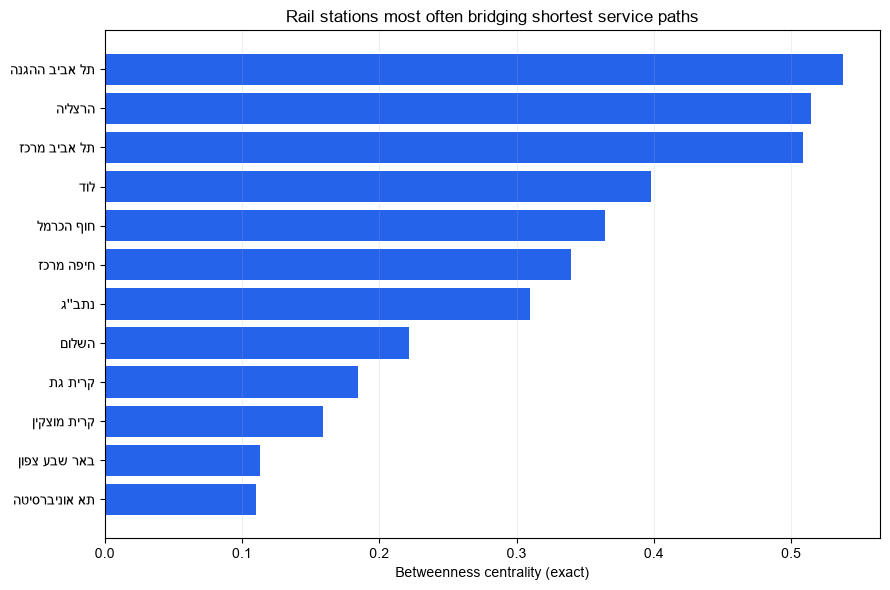

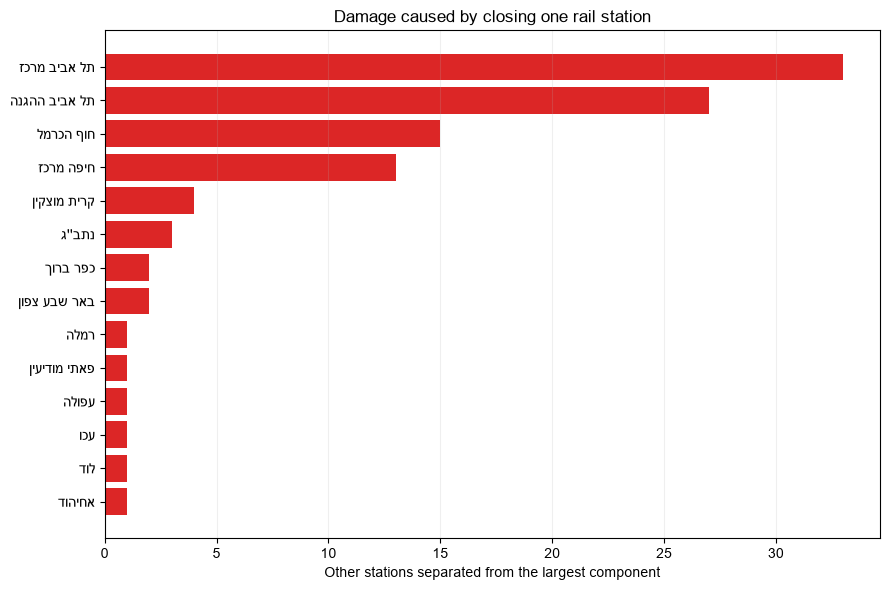

In [17]:
def plot_top_stations(metrics, path):
    top = metrics.nlargest(12, "betweenness").sort_values("betweenness")
    fig, axis = plt.subplots(figsize=(9, 6))
    axis.barh(list(top["stop_name"]), top["betweenness"], color="#2563eb")
    axis.set_xlabel("Betweenness centrality (exact)")
    axis.set_title("Rail stations most often bridging shortest service paths")
    axis.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

def plot_single_station_damage(damage, path):
    top = damage[damage["stations_outside_largest_component"] > 0].head(15)
    top = top.sort_values("stations_outside_largest_component")
    fig, axis = plt.subplots(figsize=(9, 6))
    axis.barh(
        list(top["stop_name"]),
        top["stations_outside_largest_component"],
        color="#dc2626",
    )
    axis.set_xlabel("Other stations separated from the largest component")
    axis.set_title("Damage caused by closing one rail station")
    axis.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

plot_top_stations(metrics, FIGURES / "top_betweenness_stations.png")
plot_single_station_damage(damage, FIGURES / "single_station_damage.png")

### Plot the full resilience curves and metric agreement

We use the resilience figure to track the largest component as a percentage of the original 67 stations for every targeted order and the random mean. We then use the correlation heatmap to see how strongly degree, weighted degree, PageRank, betweenness, harmonic centrality, and single-station damage move together. High correlation means two rankings are mostly redundant; lower correlation points to a different structural role.

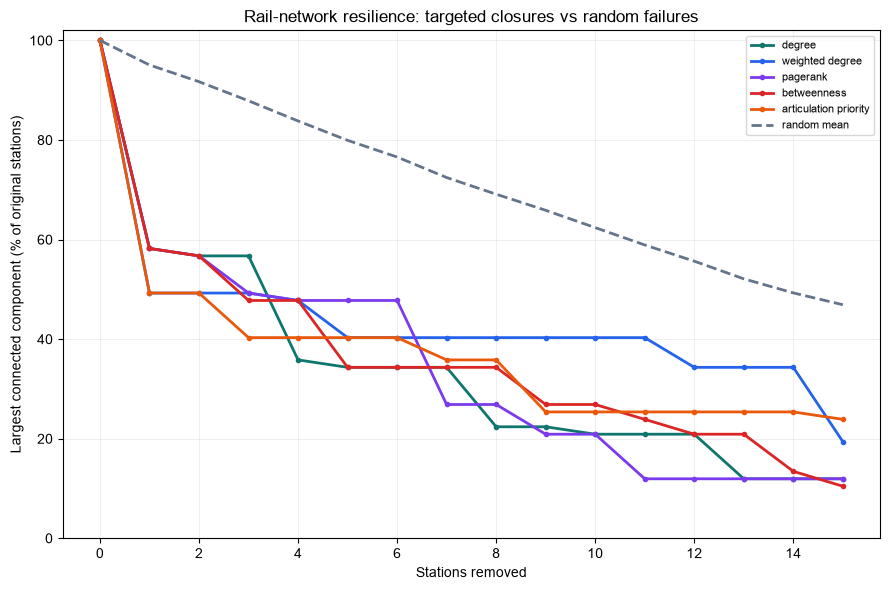

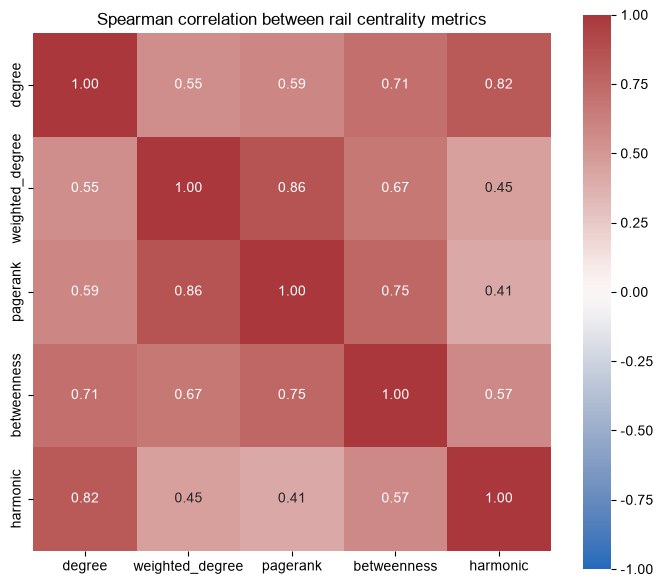

In [18]:
def plot_resilience(resilience, path):
    colors = {
        "degree": "#0f766e",
        "weighted_degree": "#2563eb",
        "pagerank": "#7c3aed",
        "betweenness": "#dc2626",
        "articulation_priority": "#ea580c",
        "random_mean": "#64748b",
    }
    fig, axis = plt.subplots(figsize=(9, 6))
    for strategy, group in resilience.groupby("strategy", sort=False):
        axis.plot(
            group["removed_stations"],
            100 * group["serviceable_share_of_original"],
            marker="o" if strategy != "random_mean" else None,
            markersize=3,
            linewidth=2,
            linestyle="--" if strategy == "random_mean" else "-",
            color=colors.get(strategy),
            label=strategy.replace("_", " "),
        )
    axis.set_xlabel("Stations removed")
    axis.set_ylabel("Largest connected component (% of original stations)")
    axis.set_title("Rail-network resilience: targeted closures vs random failures")
    axis.set_ylim(0, 102)
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

def plot_centrality_correlation(metrics, path):
    columns = ["degree", "weighted_degree", "pagerank", "betweenness", "harmonic"]
    correlation = metrics[columns].corr(method="spearman")
    fig, axis = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        correlation, annot=True, fmt=".2f", cmap="vlag",
        vmin=-1, vmax=1, square=True, ax=axis,
    )
    axis.set_title("Spearman correlation between rail centrality metrics")
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.show()

plot_resilience(resilience, FIGURES / "rail_resilience_curve.png")
plot_centrality_correlation(metrics, FIGURES / "centrality_correlation.png")

## Save all rail outputs

We write the mode inventory, station metrics, ranked stations, cut vertices, cut edges, single-station damage, resilience curves, and directed service edges as UTF-8 CSV files so Hebrew names open correctly. We also save a JSON summary containing graph counts, service dates, scan totals, and key resilience values. The final printout confirms the three output locations.

In [19]:
inventory.to_csv(TABLES / "mode_inventory.csv", index=False, encoding="utf-8-sig")
metrics.sort_values("betweenness", ascending=False).to_csv(
    TABLES / "rail_station_metrics.csv", index=False, encoding="utf-8-sig"
)
metrics.nlargest(15, "betweenness").to_csv(
    TABLES / "top_betweenness_stations.csv", index=False, encoding="utf-8-sig"
)
metrics.nlargest(15, "weighted_degree").to_csv(
    TABLES / "top_weighted_degree_stations.csv", index=False, encoding="utf-8-sig"
)
articulation_points.to_csv(
    TABLES / "rail_articulation_points.csv", index=False, encoding="utf-8-sig"
)
bridges.to_csv(TABLES / "rail_bridges.csv", index=False, encoding="utf-8-sig")
damage.to_csv(TABLES / "single_station_damage.csv", index=False, encoding="utf-8-sig")
resilience.to_csv(
    TABLES / "rail_resilience_curves.csv", index=False, encoding="utf-8-sig"
)

edge_rows = [
    {
        "from_stop_id": source,
        "to_stop_id": target,
        "scheduled_trip_segments": int(data["weight"]),
    }
    for source, target, data in directed.edges(data=True)
]
pd.DataFrame(edge_rows).sort_values("scheduled_trip_segments", ascending=False).to_csv(
    TABLES / "rail_service_edges.csv", index=False, encoding="utf-8-sig"
)

build_summary = {
    "source_stop_time_rows": int(source_rows),
    "rail_stop_time_rows": int(rail_rows),
    "rail_route_records": int(len(rail_routes)),
    "unique_route_descriptions": int(rail_routes["route_long_name"].nunique()),
    "scheduled_rail_trips": int(len(rail_trips)),
    "active_rail_stations": int(undirected.number_of_nodes()),
    "directed_service_edges": int(directed.number_of_edges()),
    "undirected_service_edges": int(undirected.number_of_edges()),
    "service_start_date": start_date,
    "service_end_date": end_date,
}
with (STAGE / "summary.json").open("w", encoding="utf-8") as handle:
    json.dump(
        {"build": build_summary, "network": summary},
        handle, ensure_ascii=False, indent=2,
    )

print("tables written to :", TABLES)
print("figures written to:", FIGURES)
print("summary written to:", STAGE / "summary.json")

tables written to : /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/11_rail_network_analysis/tables
figures written to: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/11_rail_network_analysis/figures
summary written to: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/11_rail_network_analysis/summary.json


## Conclusions

1. **The rail service graph is small, connected, and sparse.** This snapshot contains 67 active rail stations and 99 undirected service edges, with average degree `2.955`, density `0.0448`, and eight Louvain communities. The mean shortest path is 5.626 station hops and the diameter is 13.

2. **Strict cut structures are common.** We find 14 articulation stations and 11 bridge edges. That means about one in five stations can split the scheduled-service graph when removed. These are graph facts for this snapshot and service definition, not scores chosen by a percentile threshold.

3. **Tel Aviv Center is the worst single closure in this model.** Removing it leaves a largest component of 33 stations, or 49.3% of the original graph. Tel Aviv HaHagana is next at 58.2%, followed by Hof HaCarmel at 76.1%. By comparison, one random closure leaves 96.0% connected on average. The worst-versus-random gap is 46.7 percentage points.

4. **Target choice matters throughout the sequence.** After five removals, the largest component is about 34.3% under the betweenness order and 40.3% under the articulation-priority order, versus 80.2% under random removal. No one centrality order dominates at every step, which is another reason to keep the observed-damage ranking beside the proxy measures.

5. **Centrality and criticality overlap but are not identical.** Tel Aviv HaHagana has the highest betweenness, while Tel Aviv Center causes the largest one-station fragmentation. Some low-betweenness articulation stations only guard a short branch. A traffic-only ranking would miss those local cut points.

We need to keep the model limits attached to these numbers. Consecutive scheduled stops are not necessarily adjacent tracks, edge weights are trip records rather than service days or riders, the timetable window is 2026-04-19 through 2026-05-19, and the attack orders are static. This is a topology-of-service result; infrastructure capacity, replacement buses, passenger demand, and adaptive rerouting are outside this graph.